In [7]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd

from sklearn.model_selection import train_test_split


In [12]:
insurance_data = pd.read_csv("insurance.csv")


X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]


X = pd.get_dummies(X,columns=["region"],drop_first=True , dtype = int)   

X["sex"] = X["sex"].map({"female" : 1 , "male" : 0}) 
X["smoker"] = X["smoker"].map({"yes":1 , "no" :0})



X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)



MSE: 20922527.32662988
MSE: 20921803.698431373
MSE: 20914832.635089133
MSE: 20901927.931570224
MSE: 20908106.77995452
MSE: 20890881.000633497
MSE: 20937537.133939777
MSE: 21046489.29389078
MSE: 20872844.794796687
MSE: 22423172.686023258


<Axes: >

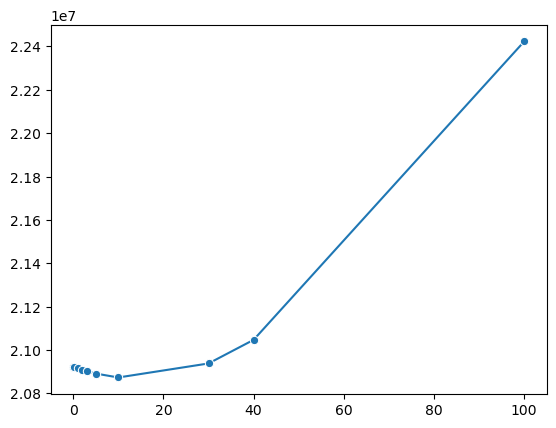

In [17]:
import seaborn as sns

alphas = [000.01 , 0.1,1,3,2,5,30, 40, 10 , 100]

mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)

    lasso_model.fit(X_train , y_train)

    y_pred = lasso_model.predict(X_test)


    mse = mean_squared_error(y_test , y_pred)
    print("MSE:" , mse)


    mses.append(mse)

sns.lineplot(x=alphas , y=mses , marker="o")
    



In [25]:
#cross validation -> lassoCV


from sklearn.linear_model import LassoCV

a= [000.01 , 0.1,1,3,2,5,30, 40, 10 , 100]



lasso_cv_model = LassoCV(

    alphas= a,
    cv=5,
    max_iter=1000,
    random_state=42
)


lasso_cv_model.fit(X_train , y_train)

print("best alpha value :" , lasso_cv_model.alpha_)


y_pred = lasso_cv_model.predict(X_test)

mse =mean_squared_error(y_test , y_pred)
print("mse:" , mse)


best alpha value : 0.01
mse: 20922527.32662988
